
**Implicit Neural Representations for Ocean State Estimation**

This notebook applies a simple INR and a PINN. It trains a model to map the four-dimensional coordinates **(longitude, latitude, depth, time)** to two oceanographic variables: temperature and salinity.

Data is sourced from the **Copernicus Marine Service** (CMEMS global ocean reanalysis at 1/12° resolution) over a small region of the Eastern Mediterranean for a 9-day window in January 2020.

Two approaches are compared:

- **INR (Implicit Neural Representation)** - a plain multi-layer perceptron trained purely on data using MSE loss.
- **PINN (Physics-Informed Neural Network)** - the same architecture with a hydrostatic constraint, penalising violations of the equation ∂ρ/∂z + ρg/c² = 0, where density ρ is computed from T and S via the **TEOS-10** equation of state.

In [ ]:
pip install copernicusmarine

In [ ]:
import copernicusmarine

In [ ]:
!pip install cartopy --quiet
!pip install gsw --quiet

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from copy import deepcopy


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


LOAD DATA

In [ ]:
LON_CENTER = 35.381
LAT_CENTER = 34.121
STEP       = 0.083
N          = 2
DATE_START = "2020-01-01"
DATE_END   = "2020-01-09"

LON_MIN = LON_CENTER - N * STEP
LON_MAX = LON_CENTER + N * STEP
LAT_MIN = LAT_CENTER - N * STEP
LAT_MAX = LAT_CENTER + N * STEP

print(f"Spatial bounding box:  lon [{LON_MIN:.3f}, {LON_MAX:.3f}]"
      f"   lat [{LAT_MIN:.3f}, {LAT_MAX:.3f}]")
print(f"Expected grid cells:   {(2*N+1)**2} horizontal points × depths × days")

df = copernicusmarine.read_dataframe(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    minimum_longitude=LON_MIN,
    maximum_longitude=LON_MAX,
    minimum_latitude=LAT_MIN,
    maximum_latitude=LAT_MAX,
    variables=["thetao", "so"],
    start_datetime=DATE_START,
    end_datetime=DATE_END,
)

df = df.reset_index()
df = df[["longitude","latitude","depth","time","thetao","so"]].dropna()
df["time_sec"] = pd.to_datetime(df["time"]).astype(np.int64) / 1e9

n_profiles = df[["longitude","latitude","time"]].drop_duplicates().shape[0]
print(f"Total samples: {df.shape[0]}  ({n_profiles} profiles)")
print(f"Unique (lon, lat) pairs: {df[['longitude','latitude']].drop_duplicates().shape[0]}")

INFO - 2026-03-25T17:21:04Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Spatial bounding box:  lon [35.215, 35.547]   lat [33.955, 34.287]
Expected grid cells:   25 horizontal points × depths × days
Copernicus Marine username: bcandido
Copernicus Marine password: ··········


INFO - 2026-03-25T17:21:24Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-03-25T17:21:24Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


Total samples: 5382  (144 profiles)
Unique (lon, lat) pairs: 16


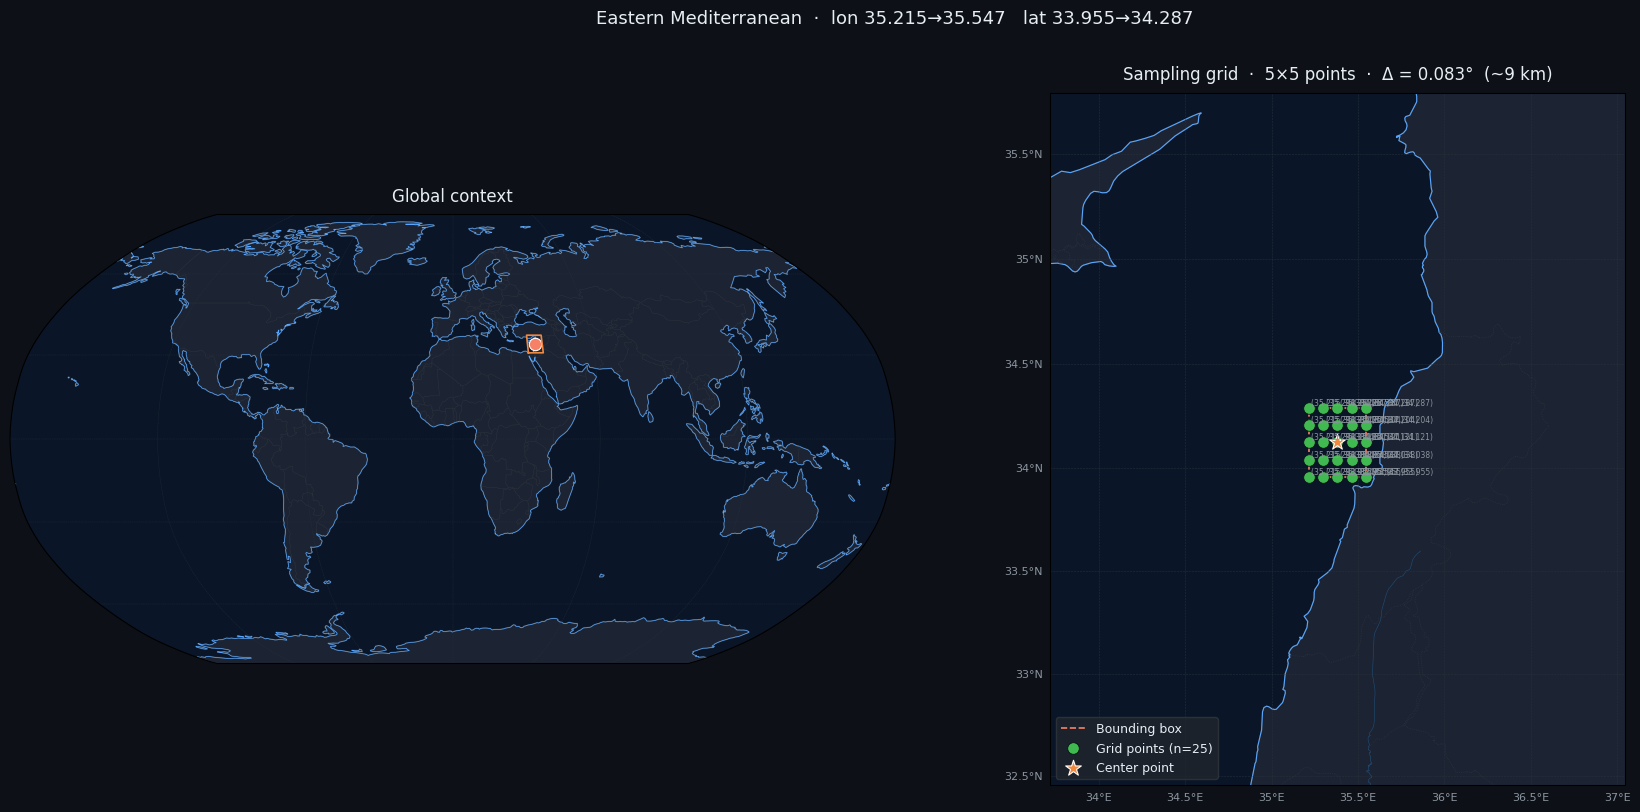

In [ ]:
#@title Coordinates
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ── Grid parameters ────────────────────────────────────────────────────────────

lons = np.round([LON_CENTER + i * STEP for i in range(-N, N+1)], 4)
lats = np.round([LAT_CENTER + i * STEP for i in range(-N, N+1)], 4)
lon_grid, lat_grid = np.meshgrid(lons, lats)

fig = plt.figure(figsize=(18, 8), facecolor="#0d1117")

# ══════════════════════════════════════════════════════════════════════════════
# LEFT — World context map
# ══════════════════════════════════════════════════════════════════════════════
ax_world = fig.add_subplot(1, 2, 1, projection=ccrs.Robinson())
ax_world.set_facecolor("#0d1117")
ax_world.set_global()

ax_world.add_feature(cfeature.OCEAN.with_scale("110m"),
                     facecolor="#0a1628", zorder=0)
ax_world.add_feature(cfeature.LAND.with_scale("110m"),
                     facecolor="#1c2333", edgecolor="#30363d", zorder=1)
ax_world.add_feature(cfeature.COASTLINE.with_scale("110m"),
                     edgecolor="#58a6ff", linewidth=0.5, zorder=2)
ax_world.add_feature(cfeature.BORDERS.with_scale("110m"),
                     edgecolor="#30363d", linewidth=0.3, zorder=2)

# Red dot on the world map
ax_world.scatter(
    LON_CENTER, LAT_CENTER,
    transform=ccrs.PlateCarree(),
    s=80, color="#f78166", edgecolors="white", linewidths=0.8,
    zorder=5
)

# Inset rectangle showing the zoom area
PAD_RECT = 3.0
rect_lons = [lons.min()-PAD_RECT, lons.max()+PAD_RECT,
             lons.max()+PAD_RECT, lons.min()-PAD_RECT, lons.min()-PAD_RECT]
rect_lats = [lats.min()-PAD_RECT, lats.min()-PAD_RECT,
             lats.max()+PAD_RECT, lats.max()+PAD_RECT, lats.min()-PAD_RECT]
ax_world.plot(rect_lons, rect_lats,
              transform=ccrs.PlateCarree(),
              color="#f0883e", lw=1.2, zorder=6)

ax_world.set_title("Global context", color="#e6edf3", fontsize=12, pad=10)

gl = ax_world.gridlines(linewidth=0.3, color="#30363d",
                         alpha=0.6, linestyle="--")

# ══════════════════════════════════════════════════════════════════════════════
# RIGHT — Zoomed regional map
# ══════════════════════════════════════════════════════════════════════════════
ax_zoom = fig.add_subplot(1, 2, 2,
            projection=ccrs.Mercator(central_longitude=LON_CENTER))
ax_zoom.set_facecolor("#0d1117")

PAD = 1.5
ax_zoom.set_extent(
    [lons.min() - PAD, lons.max() + PAD,
     lats.min() - PAD, lats.max() + PAD],
    crs=ccrs.PlateCarree()
)

ax_zoom.add_feature(cfeature.OCEAN.with_scale("10m"),
                    facecolor="#0a1628", zorder=0)
ax_zoom.add_feature(cfeature.LAND.with_scale("10m"),
                    facecolor="#1c2333", edgecolor="#30363d", zorder=1)
ax_zoom.add_feature(cfeature.COASTLINE.with_scale("10m"),
                    edgecolor="#58a6ff", linewidth=0.8, zorder=2)
ax_zoom.add_feature(cfeature.BORDERS.with_scale("10m"),
                    edgecolor="#30363d", linewidth=0.5, linestyle=":", zorder=2)
ax_zoom.add_feature(cfeature.RIVERS.with_scale("10m"),
                    edgecolor="#1f4e79", linewidth=0.4, zorder=2)

# Bounding box
bbox_lons = [lons.min(), lons.max(), lons.max(), lons.min(), lons.min()]
bbox_lats = [lats.min(), lats.min(), lats.max(), lats.max(), lats.min()]
ax_zoom.plot(bbox_lons, bbox_lats,
             transform=ccrs.PlateCarree(),
             color="#f78166", lw=1.2, ls="--", zorder=3, label="Bounding box")

# Grid points
ax_zoom.scatter(
    lon_grid.ravel(), lat_grid.ravel(),
    transform=ccrs.PlateCarree(),
    s=70, color="#3fb950", edgecolors="#0d1117", linewidths=0.6,
    zorder=5, label=f"Grid points (n={lon_grid.size})"
)

# Center point
ax_zoom.scatter(
    LON_CENTER, LAT_CENTER,
    transform=ccrs.PlateCarree(),
    s=140, color="#f0883e", edgecolors="white", linewidths=0.8,
    marker="*", zorder=6, label="Center point"
)

# Point labels
for lo, la in zip(lon_grid.ravel(), lat_grid.ravel()):
    ax_zoom.text(lo + 0.015, la + 0.015, f"({lo:.3f}, {la:.3f})",
                 transform=ccrs.PlateCarree(),
                 fontsize=5.5, color="#8b949e", zorder=7)

gl2 = ax_zoom.gridlines(draw_labels=True, crs=ccrs.PlateCarree(),
                         linewidth=0.4, color="#30363d",
                         alpha=0.7, linestyle="--")
gl2.top_labels   = False
gl2.right_labels = False
gl2.xlabel_style = {"color": "#8b949e", "fontsize": 8}
gl2.ylabel_style = {"color": "#8b949e", "fontsize": 8}

ax_zoom.legend(
    facecolor="#21262d", edgecolor="#30363d",
    labelcolor="#e6edf3", fontsize=9, loc="lower left"
)
ax_zoom.set_title(
    f"Sampling grid  ·  {N*2+1}×{N*2+1} points  ·  Δ = {STEP}°  (~9 km)",
    color="#e6edf3", fontsize=12, pad=10
)

fig.suptitle(
    f"Eastern Mediterranean  ·  lon {lons.min():.3f}→{lons.max():.3f}"
    f"   lat {lats.min():.3f}→{lats.max():.3f}",
    color="#e6edf3", fontsize=13, y=1.01
)

plt.tight_layout()
plt.savefig("sampling_grid_map.png", dpi=150,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()

Pre-processing Dataset

In [ ]:
df = df.reset_index()                    # flatten MultiIndex → plain columns
df = df[["longitude","latitude","depth","time","thetao","so"]].dropna()
df["time_sec"] = pd.to_datetime(df["time"]).astype(np.int64) / 1e9

print(f"Dataset: {df.shape[0]} samples")

Dataset: 5382 samples


In [ ]:
COORDS  = ["longitude","latitude","depth","time_sec"]
TARGETS = ["thetao","so"] # T e S

X_raw = df[COORDS].values.astype(np.float32)
Y_raw = df[TARGETS].values.astype(np.float32)

x_scaler = MinMaxScaler() # escale [0,1]
X = x_scaler.fit_transform(X_raw).astype(np.float32)

y_scaler = MinMaxScaler()
Y = y_scaler.fit_transform(Y_raw).astype(np.float32) # apply fit and transform: X_scaled = (X - min) / (max - min)

# Train / val split
np.random.seed(42)
idx   = np.random.permutation(len(X))
n_val = max(1, int(0.15 * len(X))) # check if this order is right or if should be the opposite
val_idx, trn_idx = idx[:n_val], idx[n_val:]

class OceanDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

trn_loader = DataLoader(OceanDataset(X[trn_idx], Y[trn_idx]), batch_size=512, shuffle=True)
val_loader = DataLoader(OceanDataset(X[val_idx], Y[val_idx]), batch_size=512)
print(f"Train: {len(trn_idx)}  Val: {len(val_idx)}")

Train: 4575  Val: 807


Simple INR Model

In [ ]:
class INR(nn.Module):
    """
    Implicit Neural Representation — plain MLP
    (lon, lat, depth, time) → (thetao, so)
    """
    def __init__(self, in_dim=4, hidden=256, n_layers=4, out_dim=2):
        super().__init__()

        layers = []
        layers.append(nn.Linear(in_dim, hidden))
        layers.append(nn.ReLU())

        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden, hidden))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(hidden, out_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model_inr = INR().to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model_inr.parameters()):,}")

Parameters: 199,170


In [ ]:
LR, EPOCHS, PATIENCE = 3e-4, 200, 25

optimiser = torch.optim.AdamW(model_inr.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS)
criterion = nn.MSELoss()

history = {"trn": [], "val": []}
best_val, best_state, wait = np.inf, None, 0

for epoch in range(1, EPOCHS + 1):
    model_inr.train()
    trn_loss = 0.0
    for xb, yb in trn_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        loss = criterion(model_inr(xb), yb)
        loss.backward()
        optimiser.step()
        trn_loss += loss.item() * len(xb)
    trn_loss /= len(trn_idx)

    model_inr.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(model_inr(xb), yb).item() * len(xb)
    val_loss /= len(val_idx)

    history["trn"].append(trn_loss)
    history["val"].append(val_loss)
    scheduler.step()

    if val_loss < best_val:
        best_val, best_state, wait = val_loss, deepcopy(model_inr.state_dict()), 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stop at epoch {epoch}")
            break

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}  trn {trn_loss:.6f}  val {val_loss:.6f}")

model_inr.load_state_dict(best_state)
print(f"Best val MSE: {best_val:.6f}")

Epoch   1  trn 0.378280  val 0.266938
Epoch  20  trn 0.003100  val 0.002774
Epoch  40  trn 0.001556  val 0.001326
Epoch  60  trn 0.000852  val 0.000731
Epoch  80  trn 0.000599  val 0.000532
Epoch 100  trn 0.000484  val 0.000444
Epoch 120  trn 0.000420  val 0.000388
Epoch 140  trn 0.000375  val 0.000348
Epoch 160  trn 0.000352  val 0.000327
Epoch 180  trn 0.000342  val 0.000320
Epoch 200  trn 0.000340  val 0.000319
Best val MSE: 0.000319


TEOS-10 density via gsw

In [ ]:
import gsw

def teos10_density(T, S, depth):
    """
    In-situ density via the official gsw TEOS-10 library.

    Parameters
    ----------
    T     : torch.Tensor  — potential temperature (°C),  shape (N,)
    S     : torch.Tensor  — practical salinity (PSU),    shape (N,)
    depth : torch.Tensor  — depth in metres,             shape (N,)

    Returns
    -------
    rho   : torch.Tensor  — in-situ density (kg/m³),     shape (N,)
    """
    T_np     = T.detach().cpu().numpy()
    S_np     = S.detach().cpu().numpy()
    depth_np = depth.detach().cpu().numpy()

    p_np   = gsw.p_from_z(-depth_np, lat=LAT_CENTER)
    SA_np  = gsw.SA_from_SP(S_np, p_np, lon=LON_CENTER, lat=LAT_CENTER)
    CT_np  = gsw.CT_from_pt(SA_np, T_np)
    rho_np = gsw.rho(SA_np, CT_np, p_np)

    return torch.tensor(rho_np, dtype=T.dtype, device=T.device)

PINN

Physics loss (hydrostatic soft constraint)

### Equation of State

$$
\rho = \rho(T, S, z)
$$

### Hydrostatic Constraint

$$
\frac{d\rho}{dz} + \frac{\rho g}{c^2} = 0
$$

### Physics Loss

$$
\mathcal{L}_{physics} = \frac{1}{N} \sum_{i=1}^{N} \left( \frac{d\rho}{dz} + \frac{\rho g}{c^2} \right)^2
$$

In [ ]:
def physics_loss(model, x_batch, x_scaler_, y_scaler_):
    """
    Hydrostatic residual:   dρ/dz + ρ·g/c²  =  0
    means density should vary with depth in a physically consistent way
    """
    G     = 9.81 # gravity (m/s²)
    C_SND = 1500.0 # speed of sound in water (m/s)
    DZ    = 1.0    # finite difference step in metres (small depth step (1 meter))

    mins  = torch.tensor(y_scaler_.data_min_,   dtype=x_batch.dtype, device=x_batch.device)
    scale = torch.tensor(y_scaler_.data_range_,  dtype=x_batch.dtype, device=x_batch.device)

    depth_min   = float(x_scaler_.data_min_[2])
    depth_range = float(x_scaler_.data_range_[2])
    dz_norm     = DZ / depth_range

    # Perturbed inputs
    x_up        = x_batch.clone(); x_up[:, 2]   += dz_norm
    x_down      = x_batch.clone(); x_down[:, 2] -= dz_norm

    # Predictions at z, z+dz, z-dz
    pred_c = model(x_batch) * scale + mins
    pred_u = model(x_up)    * scale + mins
    pred_d = model(x_down)  * scale + mins

    T_c, S_c = pred_c[:, 0], pred_c[:, 1]
    T_u, S_u = pred_u[:, 0], pred_u[:, 1]
    T_d, S_d = pred_d[:, 0], pred_d[:, 1]

    depth_phys = x_batch[:, 2] * depth_range + depth_min

    # TEOS-10 densities
    rho_c = teos10_density(T_c, S_c, depth_phys)
    rho_u = teos10_density(T_u, S_u, depth_phys + DZ)
    rho_d = teos10_density(T_d, S_d, depth_phys - DZ)

    # Central difference dρ/dz
    drho_dz  = (rho_u - rho_d) / (2.0 * DZ)
    residual = drho_dz + rho_c * G / C_SND**2

    return (residual**2).mean()


Training: add physics loss to INR

In [ ]:
model_pinn = INR().to(DEVICE)

In [ ]:
LR         = 3e-4
EPOCHS     = 200
PATIENCE   = 25
LAMBDA_PHY = 0.1

optimiser = torch.optim.AdamW(model_pinn.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS)
criterion = nn.MSELoss()

history = {"trn": [], "val": [], "phy": []}
best_val, best_state, wait = np.inf, None, 0

for epoch in range(1, EPOCHS + 1):

    model_pinn.train()
    trn_loss = phy_acc = 0.0

    for xb, yb in trn_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()

        data_loss = criterion(model_pinn(xb), yb)
        phy_loss  = physics_loss(model_pinn, xb, x_scaler, y_scaler)
        loss      = data_loss + LAMBDA_PHY * phy_loss

        loss.backward()
        optimiser.step()

        trn_loss += data_loss.item() * len(xb)
        phy_acc  += phy_loss.item()  * len(xb)

    trn_loss /= len(trn_idx)
    phy_acc  /= len(trn_idx)

    model_pinn.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(model_pinn(xb), yb).item() * len(xb)
    val_loss /= len(val_idx)

    history["trn"].append(trn_loss)
    history["val"].append(val_loss)
    history["phy"].append(phy_acc)
    scheduler.step()

    if val_loss < best_val:
        best_val, best_state, wait = val_loss, deepcopy(model_pinn.state_dict()), 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stop at epoch {epoch}")
            break

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | data {trn_loss:.6f} | "
              f"val {val_loss:.6f} | physics {phy_acc:.6f}")

model_pinn.load_state_dict(best_state)
print(f"\nBest val MSE: {best_val:.6f}")

Epoch   1 | data 0.417900 | val 0.301024 | physics 0.000079
Epoch  20 | data 0.003605 | val 0.003116 | physics 0.000122
Epoch  40 | data 0.001652 | val 0.001440 | physics 0.000113
Epoch  60 | data 0.000972 | val 0.000850 | physics 0.000104
Epoch  80 | data 0.000668 | val 0.000585 | physics 0.000100
Epoch 100 | data 0.000517 | val 0.000460 | physics 0.000098
Epoch 120 | data 0.000441 | val 0.000393 | physics 0.000097
Epoch 140 | data 0.000397 | val 0.000358 | physics 0.000097
Epoch 160 | data 0.000370 | val 0.000338 | physics 0.000097
Epoch 180 | data 0.000361 | val 0.000331 | physics 0.000097
Epoch 200 | data 0.000359 | val 0.000329 | physics 0.000097

Best val MSE: 0.000329


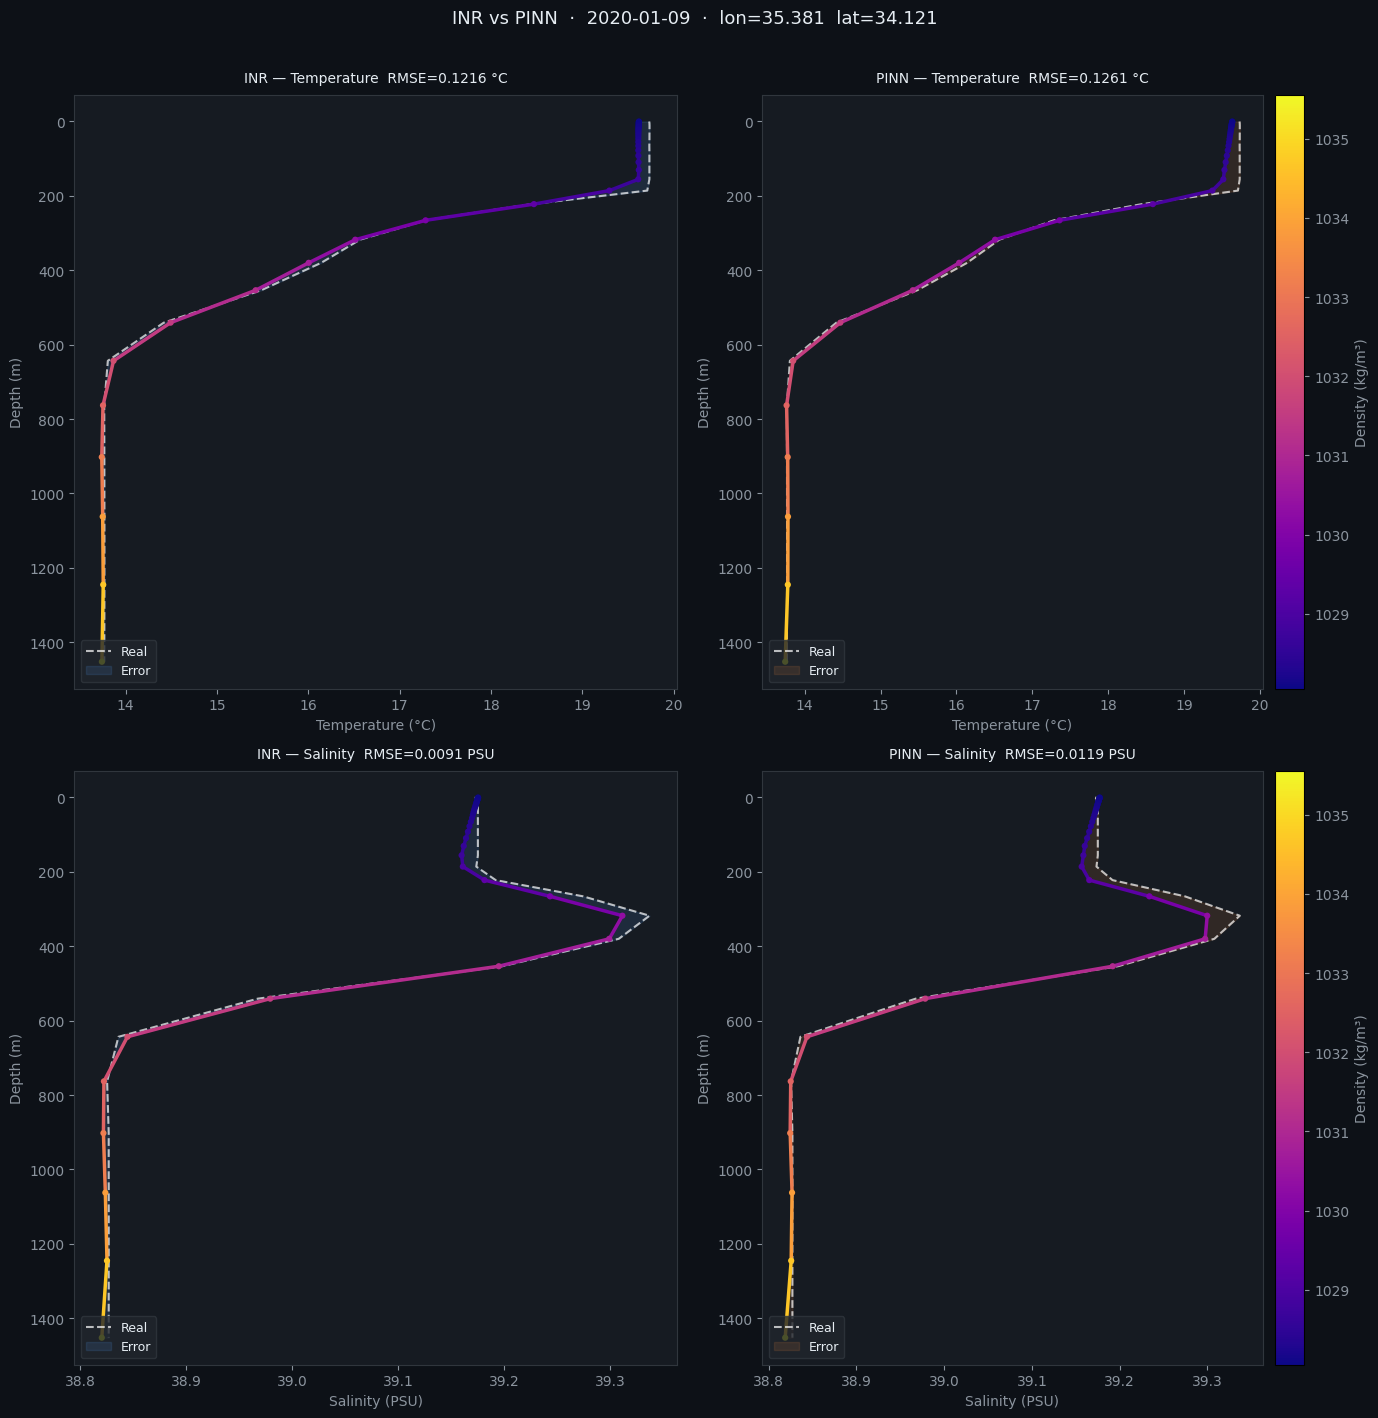

In [ ]:

#@title Profile plots — INR vs PINN coloured by density

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
import numpy as np

date_str     = DATE_END
depths_query = np.array(sorted(df["depth"].unique()))

# ── Query both models ─────────────────────────────────────────────────────────
def query_model_full(m, lon, lat, depths_m, time_str):
    """Returns DataFrame with predictions + real data + density."""
    t_sec  = pd.Timestamp(time_str).timestamp()
    coords = np.array([[lon, lat, d, t_sec] for d in depths_m], dtype=np.float32)
    cn     = x_scaler.transform(coords)
    m.eval()
    with torch.no_grad():
        pred_n = m(torch.from_numpy(cn).to(DEVICE)).cpu().numpy()
    pred = y_scaler.inverse_transform(pred_n)

    # Density via TEOS-10
    T_pred = torch.tensor(pred[:, 0])
    S_pred = torch.tensor(pred[:, 1])
    D      = torch.tensor(depths_m.astype(np.float32))
    rho    = teos10_density(T_pred, S_pred, D).numpy()

    # Real data at center point
    target_date = pd.Timestamp(time_str)
    real = df[
        (np.abs(df["longitude"] - lon) < STEP / 2) &
        (np.abs(df["latitude"]  - lat) < STEP / 2) &
        (pd.to_datetime(df["time"]) == target_date)
    ].set_index("depth")[["thetao", "so"]].sort_index()

    T_real, S_real = [], []
    for d in depths_m:
        nearest = real.index[np.argmin(np.abs(real.index - d))]
        T_real.append(real.loc[nearest, "thetao"])
        S_real.append(real.loc[nearest, "so"])

    return pd.DataFrame({
        "depth_m"      : depths_m,
        "T_predicted"  : pred[:, 0],
        "T_real"       : np.array(T_real),
        "T_error"      : pred[:, 0] - np.array(T_real),
        "S_predicted"  : pred[:, 1],
        "S_real"       : np.array(S_real),
        "S_error"      : pred[:, 1] - np.array(S_real),
        "density_kg_m3": rho,
    })

result_inr  = query_model_full(model_inr,  LON_CENTER, LAT_CENTER, depths_query, date_str)
result_pinn = query_model_full(model_pinn, LON_CENTER, LAT_CENTER, depths_query, date_str)

# ── Shared density colormap range ─────────────────────────────────────────────
rho_min = min(result_inr["density_kg_m3"].min(), result_pinn["density_kg_m3"].min())
rho_max = max(result_inr["density_kg_m3"].max(), result_pinn["density_kg_m3"].max())
norm    = mcolors.Normalize(vmin=rho_min, vmax=rho_max)
cmap    = cm.plasma

# ── Helpers ───────────────────────────────────────────────────────────────────
def dark_ax(ax, title):
    ax.set_facecolor("#161b22")
    ax.set_title(title, color="#e6edf3", fontsize=10, pad=9)
    ax.tick_params(colors="#8b949e")
    for sp in ax.spines.values():
        sp.set_edgecolor("#30363d")
    ax.xaxis.label.set_color("#8b949e")
    ax.yaxis.label.set_color("#8b949e")
    return ax

def plot_profile(ax, x_pred, x_real, depths, density, error_color):
    """Predicted line coloured by density + dashed real + error shading."""
    # Coloured predicted line
    pts  = np.array([x_pred, depths]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap=cmap, norm=norm, lw=2.5, zorder=3)
    lc.set_array(density[:-1])
    ax.add_collection(lc)

    # Dots coloured by density
    ax.scatter(x_pred, depths, c=density, cmap=cmap, norm=norm,
               s=20, zorder=4, edgecolors="none")

    # Real data
    ax.plot(x_real, depths, color="white", lw=1.5, ls="--",
            alpha=0.7, zorder=2, label="Real")

    # Error shading
    ax.fill_betweenx(depths, x_pred, x_real,
                     alpha=0.12, color=error_color, zorder=1, label="Error")

# ── Figure: 2 rows (T, S) × 2 cols (INR, PINN) ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 14), facecolor="#0d1117")

rmse = {
    "inr_T" : np.sqrt((result_inr["T_error"]**2).mean()),
    "inr_S" : np.sqrt((result_inr["S_error"]**2).mean()),
    "pinn_T": np.sqrt((result_pinn["T_error"]**2).mean()),
    "pinn_S": np.sqrt((result_pinn["S_error"]**2).mean()),
}

configs = [
    # (row, col, result,      var_pred,       var_real,   unit,  error_color, title)
    (0, 0, result_inr,  "T_predicted", "T_real", "°C",  "#58a6ff",
     f"INR — Temperature  RMSE={rmse['inr_T']:.4f} °C"),
    (0, 1, result_pinn, "T_predicted", "T_real", "°C",  "#f0883e",
     f"PINN — Temperature  RMSE={rmse['pinn_T']:.4f} °C"),
    (1, 0, result_inr,  "S_predicted", "S_real", "PSU", "#58a6ff",
     f"INR — Salinity  RMSE={rmse['inr_S']:.4f} PSU"),
    (1, 1, result_pinn, "S_predicted", "S_real", "PSU", "#f0883e",
     f"PINN — Salinity  RMSE={rmse['pinn_S']:.4f} PSU"),
]

for row, col, res, pred_col, real_col, unit, ecol, title in configs:
    ax = dark_ax(axes[row, col], title)

    plot_profile(
        ax,
        x_pred   = res[pred_col].values,
        x_real   = res[real_col].values,
        depths   = res["depth_m"].values,
        density  = res["density_kg_m3"].values,
        error_color = ecol,
    )

    ax.invert_yaxis()
    ax.autoscale_view()
    ax.set_xlabel(f"{'Temperature' if row==0 else 'Salinity'} ({unit})")
    ax.set_ylabel("Depth (m)")
    ax.legend(facecolor="#21262d", edgecolor="#30363d",
              labelcolor="#e6edf3", fontsize=9, loc="lower left")

    # Colorbar only on right column
    if col == 1:
        cb = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),
                          ax=ax, pad=0.02)
        cb.set_label("Density (kg/m³)", color="#8b949e")
        cb.ax.yaxis.label.set_color("#8b949e")
        cb.ax.tick_params(colors="#8b949e")

fig.suptitle(
    f"INR vs PINN  ·  {date_str}  ·  "
    f"lon={LON_CENTER}  lat={LAT_CENTER}",
    color="#e6edf3", fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig("profiles_inr_vs_pinn_density.png", dpi=150,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()